# GoogLeNet — ImageNet subset


## Import dan konfigurasi


In [ ]:
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
BATCH_SIZE = 64
EPOCHS = 50
TRAIN_SAMPLES = 5000
VAL_SAMPLES = 1000

## Seed untuk reproduksibilitas


In [ ]:
def set_seed(seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## Dataset dan DataLoader


In [ ]:
def get_dataloaders():
    transform_train = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ])

    transform_test = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ])

    train_set = datasets.CIFAR10("./data", train=True, download=True, transform=transform_train)
    val_set = datasets.CIFAR10("./data", train=False, download=True, transform=transform_test)

    g = torch.Generator().manual_seed(SEED)
    train_idx = torch.randperm(len(train_set), generator=g)[:TRAIN_SAMPLES]
    val_idx = torch.randperm(len(val_set), generator=g)[:VAL_SAMPLES]

    train_loader = DataLoader(
        Subset(train_set, train_idx),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(
        Subset(val_set, val_idx),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    return train_loader, val_loader, len(train_set.classes)



In [11]:
train_loader, val_loader, num_classes = get_dataloaders()

print("Train asli:", len(train_loader.dataset.dataset))
print("Train yang dipakai:", len(train_loader.dataset))

print("Validation asli:", len(val_loader.dataset.dataset))
print("Validation yang dipakai:", len(val_loader.dataset))

Train asli: 100000
Train yang dipakai: 4000
Validation asli: 10000
Validation yang dipakai: 800


## Fungsi pelatihan dan evaluasi


In [12]:
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def run_training(model, model_name):
    set_seed()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_loader, val_loader, num_classes = get_dataloaders()

    model = model(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    print(f"Model: {model_name}")
    print("Dataset: ImageNet subset")
    print(f"Classes: {num_classes}")
    print(f"Device: {device}")
    print(f"Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

    return model, history, val_loader, device




## Arsitektur model


In [13]:
class InceptionBlock(nn.Module):
    def __init__(self, in_ch, c1, c3r, c3, c5r, c5, pool_proj):
        super().__init__()
        self.b1 = nn.Sequential(
            nn.Conv2d(in_ch, c1, 1),
            nn.ReLU(inplace=True)
        )
        self.b2 = nn.Sequential(
            nn.Conv2d(in_ch, c3r, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c3r, c3, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.b3 = nn.Sequential(
            nn.Conv2d(in_ch, c5r, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c5r, c5, 5, padding=2),
            nn.ReLU(inplace=True)
        )
        self.b4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_ch, pool_proj, 1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return torch.cat([self.b1(x), self.b2(x), self.b3(x), self.b4(x)], dim=1)

class GoogLeNet(nn.Module):
    def __init__(self, num_classes=1000):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.inc1 = InceptionBlock(64, 24, 24, 32, 8, 8, 16)
        self.inc2 = InceptionBlock(80, 32, 32, 48, 8, 16, 16)
        self.pool = nn.MaxPool2d(3, stride=2, padding=1)
        self.inc3 = InceptionBlock(112, 48, 32, 48, 8, 16, 16)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.inc1(x)
        x = self.inc2(x)
        x = self.pool(x)
        x = self.inc3(x)
        return self.head(x)



## Jalankan pelatihan


In [14]:
trained_model, history, val_loader, device = run_training(GoogLeNet, "GoogLeNet")


Model: GoogLeNet
Dataset: ImageNet subset
Classes: 200
Device: cuda
Parameters: 115,320
Epoch 01/50 | train_loss=5.3011 | train_acc=0.0043 | val_loss=5.3017 | val_acc=0.0050
Epoch 02/50 | train_loss=5.2745 | train_acc=0.0077 | val_loss=5.2679 | val_acc=0.0037
Epoch 03/50 | train_loss=5.1763 | train_acc=0.0095 | val_loss=5.2267 | val_acc=0.0050
Epoch 04/50 | train_loss=5.1298 | train_acc=0.0143 | val_loss=5.2047 | val_acc=0.0100
Epoch 05/50 | train_loss=5.1104 | train_acc=0.0138 | val_loss=5.2063 | val_acc=0.0100
Epoch 06/50 | train_loss=5.0818 | train_acc=0.0152 | val_loss=5.1883 | val_acc=0.0100
Epoch 07/50 | train_loss=5.0591 | train_acc=0.0135 | val_loss=5.1965 | val_acc=0.0187
Epoch 08/50 | train_loss=5.0369 | train_acc=0.0170 | val_loss=5.1782 | val_acc=0.0100
Epoch 09/50 | train_loss=5.0077 | train_acc=0.0213 | val_loss=5.1642 | val_acc=0.0150
Epoch 10/50 | train_loss=4.9781 | train_acc=0.0195 | val_loss=5.1216 | val_acc=0.0125
Epoch 11/50 | train_loss=4.9397 | train_acc=0.0248 |

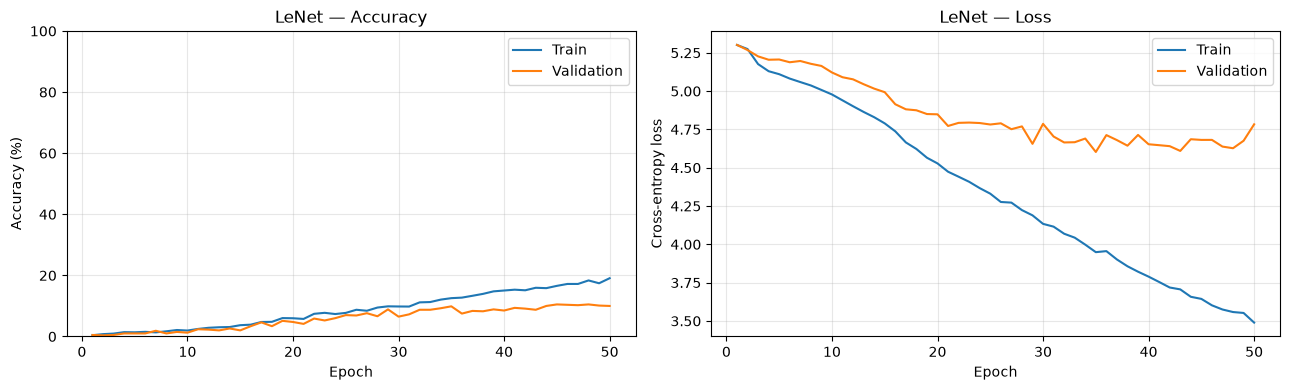

In [15]:
import matplotlib.pyplot as plt

if "history" not in globals() or not history["train_loss"]:
    raise RuntimeError("Jalankan ulang sel fungsi pelatihan dan sel pelatihan terlebih dahulu.")

epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, [acc * 100 for acc in history["train_acc"]], label="Train")
axes[0].plot(epochs, [acc * 100 for acc in history["val_acc"]], label="Validation")
axes[0].set_title("LeNet — Accuracy")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)

axes[1].plot(epochs, history["train_loss"], label="Train")
axes[1].plot(epochs, history["val_loss"], label="Validation")
axes[1].set_title("LeNet — Loss")
axes[1].set_ylabel("Cross-entropy loss")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


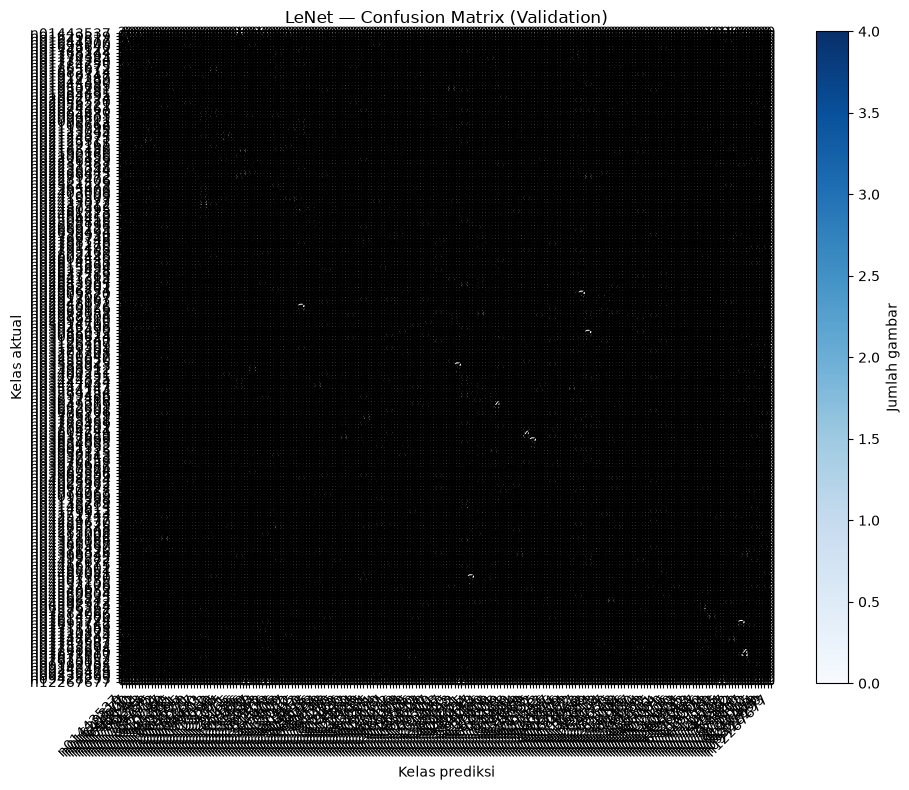

In [16]:
import matplotlib.pyplot as plt

@torch.no_grad()
def get_confusion_matrix(model, loader, device, num_classes):
    model.eval()
    matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for images, labels in loader:
        predictions = model(images.to(device)).argmax(dim=1).cpu()
        indices = labels.cpu() * num_classes + predictions
        matrix += torch.bincount(indices, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return matrix

if any(name not in globals() for name in ("trained_model", "val_loader", "device")):
    raise RuntimeError("Jalankan ulang sel fungsi pelatihan dan sel pelatihan terlebih dahulu.")

class_names = val_loader.dataset.dataset.classes
num_classes = len(class_names)
confusion_matrix = get_confusion_matrix(trained_model, val_loader, device, num_classes)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(confusion_matrix.numpy(), cmap="Blues", interpolation="nearest")
fig.colorbar(image, ax=ax, label="Jumlah gambar")
ax.set_xticks(range(num_classes), labels=class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes), labels=class_names)
ax.set_xlabel("Kelas prediksi")
ax.set_ylabel("Kelas aktual")
ax.set_title("LeNet — Confusion Matrix (Validation)")

threshold = confusion_matrix.max().item() / 2
for row in range(num_classes):
    for col in range(num_classes):
        count = confusion_matrix[row, col].item()
        ax.text(col, row, str(count), ha="center", va="center",
                color="white" if count > threshold else "black")

plt.tight_layout()
plt.show()
